In [13]:
# PHYS 311
# LAB 1 - PROJECTILE MOTION SOLVER
# Alexander Berry
# August 25, 2026

# IMPORT TOOLS

import numpy as np
import matplotlib.pyplot as plt


# PERCENT ERROR FUNCTION

def percent_error(numerical, exact):
    return abs(numerical - exact) / abs(exact) * 100

## Part A - One-Dimensional Free Fall

In this part, we must simulate a ball being dropped from rest at a height of 100 m using the Euler method. We must also compare the numerical solution with the "exact" analytical solution for free fall.

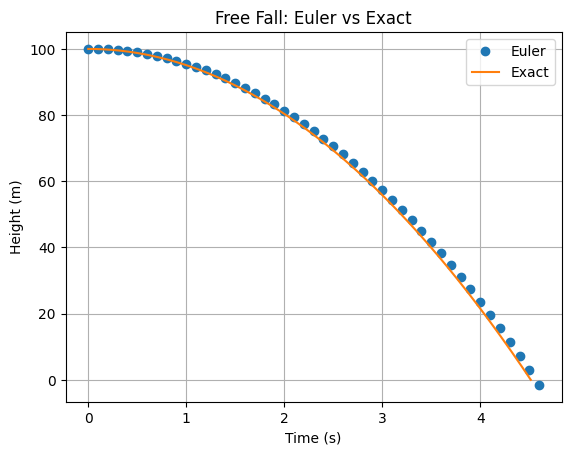

PART A
Numerical landing time: 4.6 s
Exact landing time: 4.515236409857309 s
Time error: 1.877279115610462 %

Numerical final velocity: -45.12600000000005 m/s
Exact final velocity: -44.294469180700204 m/s
Velocity error: 1.8772791156105646 %

TIME STEP COMPARISON
dt = 1.0
Landing time = 6.0
Error = 32.88340754210061 %

dt = 0.1
Landing time = 4.6
Error = 1.877279115610462 %

dt = 0.01
Landing time = 4.529999999999948
Error = 0.3269726942848076 %



In [14]:
# PART A - FREE FALL


# A1. FREE FALL FUNCTION

def simulate_freefall(h, dt, g=9.81):

    # Starting values
    t = 0
    y = h
    vy = 0

    # Lists to save each value
    times = [t]
    positions = [y]
    velocities = [vy]

    # Calculate until the ball passes the ground
    while y >= 0:

        # Gravity is the only acceleration
        ay = -g

        # Euler method
        y = y + vy * dt
        vy = vy + ay * dt
        t = t + dt

        # Save new values
        times.append(t)
        positions.append(y)
        velocities.append(vy)

    return np.array(times), np.array(positions), np.array(velocities)


# A2. RUN FREE FALL

h = 100
g = 9.81
dt = 0.1

t, y, vy = simulate_freefall(h, dt, g)


# A3. EXACT FREE FALL VALUES

exact_time = np.sqrt(2 * h / g)
exact_velocity = -g * exact_time

# Make exact curve
t_exact = np.linspace(0, exact_time, 500)
y_exact = h - 0.5 * g * t_exact**2


# A4. PLOT FREE FALL

plt.figure()

plt.plot(t, y, 'o', label='Euler')
plt.plot(t_exact, y_exact, label='Exact')

plt.xlabel('Time (s)')
plt.ylabel('Height (m)')
plt.title('Free Fall: Euler vs Exact')
plt.legend()
plt.grid()
plt.show()


# A5. PRINT RESULTS

numerical_time = t[-1]
numerical_velocity = vy[-1]

print("PART A")

print("Numerical landing time:", numerical_time, "s")
print("Exact landing time:", exact_time, "s")
print("Time error:", percent_error(numerical_time, exact_time), "%")

print()

print("Numerical final velocity:", numerical_velocity, "m/s")
print("Exact final velocity:", exact_velocity, "m/s")
print("Velocity error:", percent_error(numerical_velocity, exact_velocity), "%")


# A6. COMPARE DIFFERENT TIME STEPS

print()
print("TIME STEP COMPARISON")

for dt_test in [1.0, 0.1, 0.01]:

    t_test, y_test, vy_test = simulate_freefall(h, dt_test, g)

    landing_time = t_test[-1]
    error = percent_error(landing_time, exact_time)

    print("dt =", dt_test)
    print("Landing time =", landing_time)
    print("Error =", error, "%")
    print()

## Part A Questions

1. The numerical landing time was 4.60 s, compared to the exact landing time which was 4.515 s. This gave us a percentage error of ~1.88%. The numerical final velocity was -45.126 m/s, compared to the exact value of -44.294 m/s, which equally produced an error of approximately 1.88%.
2. As the timestep decreased, the numerical error also decreased. At dt = 1.0 s, the landing-time error was approximately 32.88%. Decreasing the timestep to dt = 0.1 s, reduced the error to 1.88%. Furthermore, decreasing it to dt = 0.01 s reduced the error to approximately 0.327%. This shows that using a smaller timestep makes the Euler approximation more accurate.

## Part B - Two-Dimensional Projectile Motion

In this part, we must extend the Euler method to two dimensions. The projectile is launched at 30 m/s and 45 degrees with no air resistance. We must then compare the numerical trajectory with the exact projectile-motion solution.

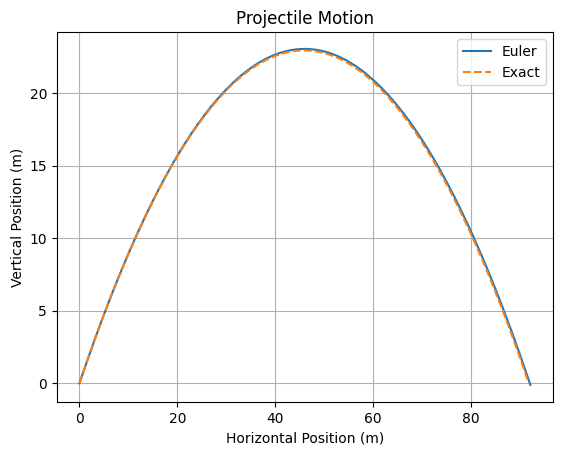

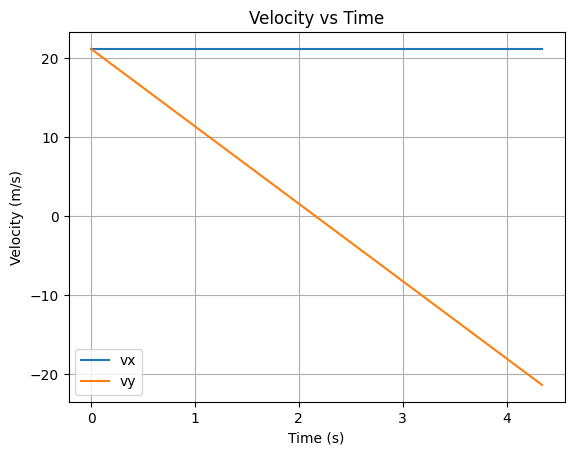


PART B
Range
Numerical: 92.06530291048838
Exact: 91.74311926605505
Error: 0.3511801724323381 %

Maximum Height
Numerical: 23.041935455244325
Exact: 22.935779816513765
Error: 0.4628385848652386 %

Flight Time
Numerical: 4.339999999999952
Exact: 4.324812117348914
Error: 0.3511801724313458 %

Best angle: 45 degrees
Maximum range: 92.06530291048838 m


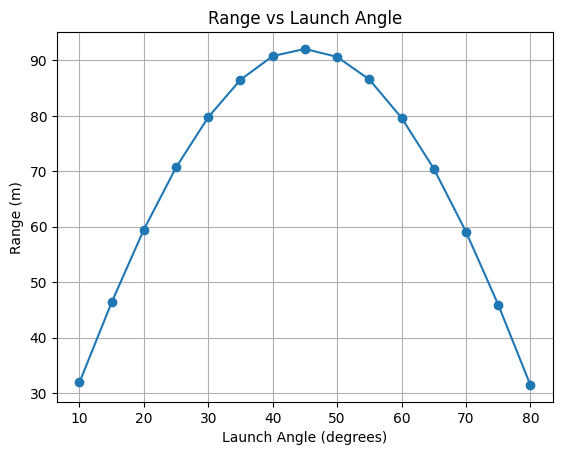

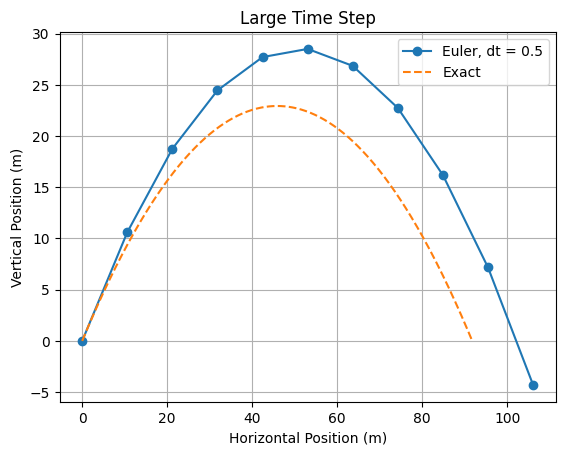

In [15]:
# PART B - 2D PROJECTILE MOTION


# B1. PROJECTILE FUNCTION

def simulate_projectile(v0, angle_deg, dt, g=9.81):

    # Convert angle to radians
    angle = np.radians(angle_deg)

    # Starting position
    t = 0
    x = 0
    y = 0

    # Starting velocity
    vx = v0 * np.cos(angle)
    vy = v0 * np.sin(angle)

    # Save values
    times = [t]
    x_values = [x]
    y_values = [y]
    vx_values = [vx]
    vy_values = [vy]

    # Continue until projectile passes ground
    while y >= 0:

        # Acceleration
        ax = 0
        ay = -g

        # Euler method
        x = x + vx * dt
        y = y + vy * dt

        vx = vx + ax * dt
        vy = vy + ay * dt

        t = t + dt

        # Save values
        times.append(t)
        x_values.append(x)
        y_values.append(y)
        vx_values.append(vx)
        vy_values.append(vy)

    return (
        np.array(times),
        np.array(x_values),
        np.array(y_values),
        np.array(vx_values),
        np.array(vy_values)
    )


# B2. RUN PROJECTILE

v0 = 30
angle = 45
dt = 0.01

t, x, y, vx, vy = simulate_projectile(v0, angle, dt, g)


# B3. EXACT VALUES

angle_rad = np.radians(angle)

exact_range = v0**2 * np.sin(2 * angle_rad) / g

exact_height = (
    v0**2 * np.sin(angle_rad)**2
    / (2 * g)
)

exact_flight_time = (
    2 * v0 * np.sin(angle_rad)
    / g
)


# B4. EXACT TRAJECTORY

x_exact = np.linspace(0, exact_range, 500)

y_exact = (
    x_exact * np.tan(angle_rad)
    - g * x_exact**2
    / (2 * v0**2 * np.cos(angle_rad)**2)
)


# B5. PLOT TRAJECTORY

plt.figure()

plt.plot(x, y, label='Euler')
plt.plot(x_exact, y_exact, '--', label='Exact')

plt.xlabel('Horizontal Position (m)')
plt.ylabel('Vertical Position (m)')
plt.title('Projectile Motion')
plt.legend()
plt.grid()
plt.show()


# B6. PLOT VELOCITIES

plt.figure()

plt.plot(t, vx, label='vx')
plt.plot(t, vy, label='vy')

plt.xlabel('Time (s)')
plt.ylabel('Velocity (m/s)')
plt.title('Velocity vs Time')
plt.legend()
plt.grid()
plt.show()


# B7. NUMERICAL RESULTS

numerical_range = x[-1]
numerical_height = np.max(y)
numerical_flight_time = t[-1]

print()
print("PART B")

print("Range")
print("Numerical:", numerical_range)
print("Exact:", exact_range)
print("Error:", percent_error(numerical_range, exact_range), "%")

print()

print("Maximum Height")
print("Numerical:", numerical_height)
print("Exact:", exact_height)
print("Error:", percent_error(numerical_height, exact_height), "%")

print()

print("Flight Time")
print("Numerical:", numerical_flight_time)
print("Exact:", exact_flight_time)
print("Error:", percent_error(numerical_flight_time, exact_flight_time), "%")


# B8. ANGLE SWEEP

angles = np.arange(10, 81, 5)
ranges = []

for angle_test in angles:

    t_test, x_test, y_test, vx_test, vy_test = simulate_projectile(
        v0,
        angle_test,
        dt,
        g
    )

    ranges.append(x_test[-1])


# B9. FIND BEST ANGLE

best_index = np.argmax(ranges)

best_angle = angles[best_index]
best_range = ranges[best_index]

print()
print("Best angle:", best_angle, "degrees")
print("Maximum range:", best_range, "m")


# B10. PLOT RANGE VS ANGLE

plt.figure()

plt.plot(angles, ranges, 'o-')

plt.xlabel('Launch Angle (degrees)')
plt.ylabel('Range (m)')
plt.title('Range vs Launch Angle')
plt.grid()
plt.show()


# B11. TEST LARGE TIME STEP

t_bad, x_bad, y_bad, vx_bad, vy_bad = simulate_projectile(
    v0,
    45,
    0.5,
    g
)

plt.figure()

plt.plot(x_bad, y_bad, 'o-', label='Euler, dt = 0.5')
plt.plot(x_exact, y_exact, '--', label='Exact')

plt.xlabel('Horizontal Position (m)')
plt.ylabel('Vertical Position (m)')
plt.title('Large Time Step')
plt.legend()
plt.grid()
plt.show()

## Part B Questions

1. The horizontal velocity vx remains constant because there are zero horizontal forces acting on the projectile, so ax = 0. The vertical velocity vy changes proportionally because gravity produces a constant downward acceleration of ay = -g.
2. The maximum numerical range occurred at 45 degrees, with a range of ~92.07 m. This does in fact agree with the theoretical prediction for projectile motion without air resistance. Additonally, the exact range was 91.74 m, so the error was ~0.35%.
3. As seen in part A, when the timestep was increased to 0.5 s, the Euler approximation became much less accurate. In this case, The numerical trajectory rose higher and traveled farther than the exact trajectory. To that end, the simulation reached a maximum height of about 28.5 m instead of 22.94 m and a range of about 106.1 m instead of 91.74 m. The larger timestep causes Euler's method to make larger approximations between calculations, which increases the numerical error.


## Part C - Projectile Motion with Air Resistance

In this part, we add quadratic air resistance to the projectile simulation. The drag force depends on the projectile's current speed and acts opposite its velocity. We then compare the resulting trajectory with the no-drag case.

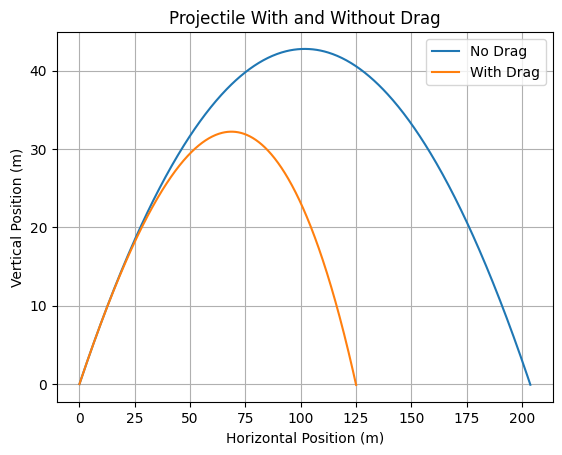


PART C
No Drag Range: 203.72951964749083 m
Drag Range: 125.00251644204612 m

No Drag Height: 42.78899018588841 m
Drag Height: 32.22441485305721 m

Range reduction: 38.64290424954837 %


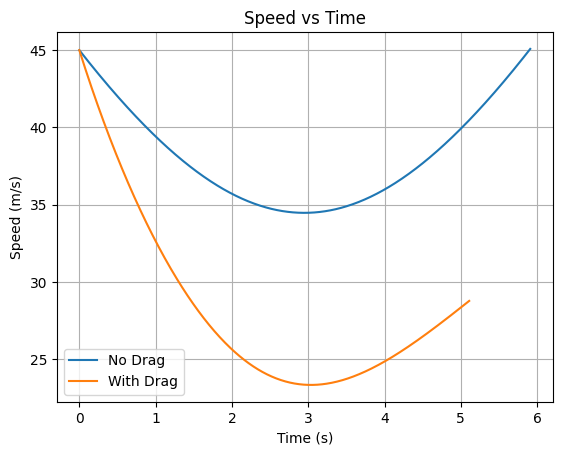


Best angle without drag: 45 degrees
Best angle with drag: 40 degrees


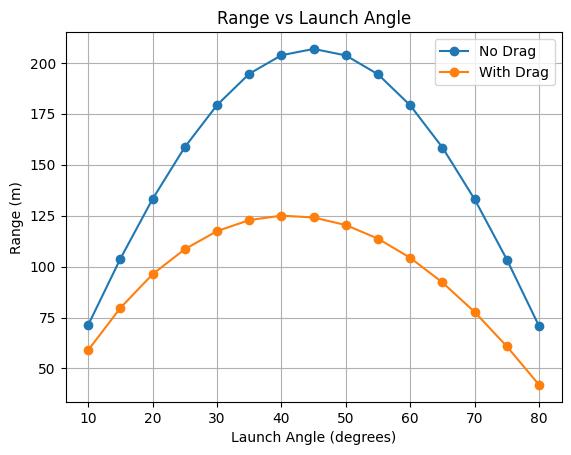

In [16]:
# PART C - PROJECTILE WITH AIR RESISTANCE


# C1. PROJECTILE WITH DRAG FUNCTION

def simulate_drag(v0, angle_deg, dt, g=9.81, b_over_m=0.0046):

    # Convert degrees to radians
    angle = np.radians(angle_deg)

    # Starting values
    t = 0
    x = 0
    y = 0

    vx = v0 * np.cos(angle)
    vy = v0 * np.sin(angle)

    # Save values
    times = [t]
    x_values = [x]
    y_values = [y]
    vx_values = [vx]
    vy_values = [vy]

    while y >= 0:

        # Current speed
        speed = np.sqrt(vx**2 + vy**2)

        # Acceleration from drag and gravity
        ax = -b_over_m * speed * vx
        ay = -g - b_over_m * speed * vy

        # Euler method
        x = x + vx * dt
        y = y + vy * dt

        vx = vx + ax * dt
        vy = vy + ay * dt

        t = t + dt

        # Save values
        times.append(t)
        x_values.append(x)
        y_values.append(y)
        vx_values.append(vx)
        vy_values.append(vy)

    return (
        np.array(times),
        np.array(x_values),
        np.array(y_values),
        np.array(vx_values),
        np.array(vy_values)
    )


# C2. BASEBALL VALUES

v0 = 45
angle = 40
dt = 0.01
b_over_m = 0.0046


# C3. RUN WITH DRAG

t_drag, x_drag, y_drag, vx_drag, vy_drag = simulate_drag(
    v0,
    angle,
    dt,
    g,
    b_over_m
)


# C4. RUN WITHOUT DRAG

t_no_drag, x_no_drag, y_no_drag, vx_no_drag, vy_no_drag = simulate_projectile(
    v0,
    angle,
    dt,
    g
)


# C5. PLOT WITH AND WITHOUT DRAG

plt.figure()

plt.plot(x_no_drag, y_no_drag, label='No Drag')
plt.plot(x_drag, y_drag, label='With Drag')

plt.xlabel('Horizontal Position (m)')
plt.ylabel('Vertical Position (m)')
plt.title('Projectile With and Without Drag')
plt.legend()
plt.grid()
plt.show()


# C6. RANGE AND HEIGHT

range_no_drag = x_no_drag[-1]
range_drag = x_drag[-1]

height_no_drag = np.max(y_no_drag)
height_drag = np.max(y_drag)

print()
print("PART C")

print("No Drag Range:", range_no_drag, "m")
print("Drag Range:", range_drag, "m")

print()

print("No Drag Height:", height_no_drag, "m")
print("Drag Height:", height_drag, "m")


# C7. PERCENT RANGE REDUCTION

range_reduction = (
    (range_no_drag - range_drag)
    / range_no_drag
    * 100
)

print()
print("Range reduction:", range_reduction, "%")


# C8. CALCULATE SPEED

speed_no_drag = np.sqrt(
    vx_no_drag**2 + vy_no_drag**2
)

speed_drag = np.sqrt(
    vx_drag**2 + vy_drag**2
)


# C9. PLOT SPEED VS TIME

plt.figure()

plt.plot(t_no_drag, speed_no_drag, label='No Drag')
plt.plot(t_drag, speed_drag, label='With Drag')

plt.xlabel('Time (s)')
plt.ylabel('Speed (m/s)')
plt.title('Speed vs Time')
plt.legend()
plt.grid()
plt.show()


# C10. ANGLE SWEEP WITH AND WITHOUT DRAG

angles = np.arange(10, 81, 5)

ranges_no_drag = []
ranges_drag = []

for angle_test in angles:

    # No drag
    t1, x1, y1, vx1, vy1 = simulate_projectile(
        v0,
        angle_test,
        dt,
        g
    )

    ranges_no_drag.append(x1[-1])


    # With drag
    t2, x2, y2, vx2, vy2 = simulate_drag(
        v0,
        angle_test,
        dt,
        g,
        b_over_m
    )

    ranges_drag.append(x2[-1])


# C11. FIND BEST ANGLES

best_no_drag = angles[np.argmax(ranges_no_drag)]

best_drag = angles[np.argmax(ranges_drag)]

print()
print("Best angle without drag:", best_no_drag, "degrees")
print("Best angle with drag:", best_drag, "degrees")


# C12. PLOT RANGE VS ANGLE

plt.figure()

plt.plot(
    angles,
    ranges_no_drag,
    'o-',
    label='No Drag'
)

plt.plot(
    angles,
    ranges_drag,
    'o-',
    label='With Drag'
)

plt.xlabel('Launch Angle (degrees)')
plt.ylabel('Range (m)')
plt.title('Range vs Launch Angle')
plt.legend()
plt.grid()
plt.show()

## Part C Questions

1. Air resistance reduces the projectile's range significantly because quadratic drag is strongest when the projectile is moving fastest (per textbook). The drag force opposes the direction of motion, causing the ball to lose horizontal velocity throughout its flight. In this simulation, the no-drag range was ~203.73 m, while the range with drag was only ~125.00 m. This concludes a range reduction of ~38.64%.
2. The optimal launch angle with drag was 40 degrees, compared with 45 degrees without drag. A higher launch angle keeps the projectile in the air longer, giving air resistance more time to remove horizontal velocity. With drag however, a slightly lower launch angle provides a much better balance between horizontal velocity and time in the air. Causing therefore the shift in optimal angles below 45 degrees.
3. Euler's method can be evaluated using a convergence test. As mentioned in our discussion posts this week, the same simulation can be repeated using progressively smaller timesteps. If values (such as the calculated range) approach a stable result as dt decreases, then the numerical solution is converging. If the result changes significantly as dt is reduced, then the original timestep was too large to provide an accuracy.

## Tools and Assistance

This week's task was admittantly difficult, but I found the right balance of using online tools and Artificial Intelligence to help formulate my results and conclusions.

My workflow for this assignment is described in greater detail in my journal. Overall however, I enjoyed breaking down the parts of a problem myself, thinking of how to solve it, and then using tools as a consultant to deliver a polished product.